In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
import math

def sigmoid(x):
    x = max(-500, min(500, x))
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)  

def tanh_act(x):
    return math.tanh(x)

def tanh_derivative(x):
    t = math.tanh(x)
    return 1 - t * t

def relu(x):
    return max(0.0, x)

def relu_derivative(x):
    return 1.0 if x > 0 else 0.0

def leaky_relu(x, alpha=0.01):
    return x if x > 0 else alpha * x

def leaky_relu_derivative(x, alpha=0.01):
    return 1.0 if x > 0 else alpha

def gelu(x):
    return 0.5 * x * (1 + math.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * x ** 3)))

def gelu_derivative(x):
    phi = 0.5 * (1 + math.erf(x / math.sqrt(2)))
    pdf = math.exp(-0.5 * x * x) / math.sqrt(2 * math.pi)
    return phi + x * pdf

def swish(x):
    return x * sigmoid(x)

def swish_derivative(x):
    s = sigmoid(x)
    return s + x * s * (1 - s)

def softmax(xs):
    max_x = max(xs)
    exps = [math.exp(x - max_x) for x in xs]
    total = sum(exps)
    return [e / total for e in exps]


def gradient_scan(name, derivative_fn, start=-5, end=5, n=100):
    step = (end - start) / n
    near_zero = 0
    healthy = 0
    for i in range(n):
        x = start + i * step
        g = derivative_fn(x)
        if abs(g) < 0.01:
            near_zero += 1
        else:
            healthy += 1
    pct_dead = near_zero / n * 100
    print(f"{name:15s}: {healthy:3d} healthy, {near_zero:3d} near-zero ({pct_dead:.0f}% dead zone)")

gradient_scan("Sigmoid", sigmoid_derivative)
gradient_scan("Tanh", tanh_derivative)
gradient_scan("ReLU", relu_derivative)
gradient_scan("Leaky ReLU", leaky_relu_derivative)
gradient_scan("GELU", gelu_derivative)
gradient_scan("Swish", swish_derivative)

import random

def vanishing_gradient_experiment(activation_fn, name, n_layers=10, n_inputs=5):
    random.seed(42)
    values = [random.gauss(0, 1) for _ in range(n_inputs)]

    print(f"\n{name} through {n_layers} layers:")
    for layer in range(n_layers):
        weights = [random.gauss(0, 1) for _ in range(n_inputs)]
        z = sum(w * v for w, v in zip(weights, values))
        activated = activation_fn(z)
        magnitude = abs(activated)
        bar = "#" * int(magnitude * 20)
        print(f"  Layer {layer+1:2d}: magnitude = {magnitude:.6f} {bar}")
        values = [activated] * n_inputs

vanishing_gradient_experiment(sigmoid, "Sigmoid")
vanishing_gradient_experiment(relu, "ReLU")
vanishing_gradient_experiment(gelu, "GELU")


def dead_neuron_detector(n_inputs=5, hidden_size=20, n_samples=1000):
    random.seed(0)
    weights = [[random.gauss(0, 1) for _ in range(n_inputs)] for _ in range(hidden_size)]
    biases = [random.gauss(0, 1) for _ in range(hidden_size)]

    fire_counts = [0] * hidden_size

    for _ in range(n_samples):
        inputs = [random.gauss(0, 1) for _ in range(n_inputs)]
        for neuron_idx in range(hidden_size):
            z = sum(w * x for w, x in zip(weights[neuron_idx], inputs)) + biases[neuron_idx]
            if relu(z) > 0:
                fire_counts[neuron_idx] += 1

    dead = sum(1 for c in fire_counts if c == 0)
    rarely_fire = sum(1 for c in fire_counts if 0 < c < n_samples * 0.05)
    healthy = hidden_size - dead - rarely_fire

    print(f"\nDead Neuron Report ({hidden_size} neurons, {n_samples} samples):")
    print(f"  Dead (never fired):     {dead}")
    print(f"  Barely alive (<5%):     {rarely_fire}")
    print(f"  Healthy:                {healthy}")
    print(f"  Dead neuron rate:       {dead/hidden_size*100:.1f}%")

    for i, c in enumerate(fire_counts):
        status = "DEAD" if c == 0 else "WEAK" if c < n_samples * 0.05 else "OK"
        bar = "#" * (c * 40 // n_samples)
        print(f"  Neuron {i:2d}: {c:4d}/{n_samples} fires [{status:4s}] {bar}")

dead_neuron_detector()


def make_circle_data(n=200, seed=42):
    random.seed(seed)
    data = []
    for _ in range(n):
        x = random.uniform(-2, 2)
        y = random.uniform(-2, 2)
        label = 1.0 if x * x + y * y < 1.5 else 0.0
        data.append(([x, y], label))
    return data


class ActivationNetwork:
    def __init__(self, activation_fn, activation_deriv, hidden_size=8, lr=0.1):
        random.seed(0)
        self.act = activation_fn
        self.act_d = activation_deriv
        self.lr = lr
        self.hidden_size = hidden_size

        self.w1 = [[random.gauss(0, 0.5) for _ in range(2)] for _ in range(hidden_size)]
        self.b1 = [0.0] * hidden_size
        self.w2 = [random.gauss(0, 0.5) for _ in range(hidden_size)]
        self.b2 = 0.0

    def forward(self, x):
        self.x = x
        self.z1 = []
        self.h = []
        for i in range(self.hidden_size):
            z = self.w1[i][0] * x[0] + self.w1[i][1] * x[1] + self.b1[i]
            self.z1.append(z)
            self.h.append(self.act(z))

        self.z2 = sum(self.w2[i] * self.h[i] for i in range(self.hidden_size)) + self.b2
        self.out = sigmoid(self.z2)
        return self.out

    def backward(self, target):
        error = self.out - target
        d_out = error * self.out * (1 - self.out)

        for i in range(self.hidden_size):
            d_h = d_out * self.w2[i] * self.act_d(self.z1[i])
            self.w2[i] -= self.lr * d_out * self.h[i]
            for j in range(2):
                self.w1[i][j] -= self.lr * d_h * self.x[j]
            self.b1[i] -= self.lr * d_h
        self.b2 -= self.lr * d_out

    def train(self, data, epochs=200):
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            correct = 0
            for x, y in data:
                pred = self.forward(x)
                self.backward(y)
                total_loss += (pred - y) ** 2
                if (pred >= 0.5) == (y >= 0.5):
                    correct += 1
            avg_loss = total_loss / len(data)
            accuracy = correct / len(data) * 100
            losses.append(avg_loss)
            if epoch % 50 == 0 or epoch == epochs - 1:
                print(f"    Epoch {epoch:3d}: loss={avg_loss:.4f}, accuracy={accuracy:.1f}%")
        return losses


data = make_circle_data()

configs = [
    ("Sigmoid", sigmoid, sigmoid_derivative),
    ("ReLU", relu, relu_derivative),
    ("GELU", gelu, gelu_derivative),
]

results = {}
for name, act_fn, act_d_fn in configs:
    print(f"\n=== Training with {name} ===")
    net = ActivationNetwork(act_fn, act_d_fn, hidden_size=8, lr=0.1)
    losses = net.train(data, epochs=200)
    results[name] = losses

print("\n=== Final Loss Comparison ===")
for name, losses in results.items():
    print(f"  {name:10s}: start={losses[0]:.4f} -> end={losses[-1]:.4f} (improvement: {(1 - losses[-1]/losses[0])*100:.1f}%)")

Sigmoid        :  91 healthy,   9 near-zero (9% dead zone)
Tanh           :  59 healthy,  41 near-zero (41% dead zone)
ReLU           :  49 healthy,  51 near-zero (51% dead zone)
Leaky ReLU     : 100 healthy,   0 near-zero (0% dead zone)
GELU           :  80 healthy,  20 near-zero (20% dead zone)
Swish          :  99 healthy,   1 near-zero (1% dead zone)

Sigmoid through 10 layers:
  Layer  1: magnitude = 0.505242 ##########
  Layer  2: magnitude = 0.672564 #############
  Layer  3: magnitude = 0.579702 ###########
  Layer  4: magnitude = 0.518791 ##########
  Layer  5: magnitude = 0.506911 ##########
  Layer  6: magnitude = 0.070461 #
  Layer  7: magnitude = 0.502930 ##########
  Layer  8: magnitude = 0.645463 ############
  Layer  9: magnitude = 0.521604 ##########
  Layer 10: magnitude = 0.662811 #############

ReLU through 10 layers:
  Layer  1: magnitude = 0.020967 
  Layer  2: magnitude = 0.029871 
  Layer  3: magnitude = 0.014281 
  Layer  4: magnitude = 0.001853 
  Layer  5: ma

In [13]:

class ActivationFunctions:
    """
    All activation functions built from scratch - no NumPy!
    """
    
    @staticmethod
    def relu(x):
        """
        ReLU from scratch: max(0, x)
        Works with single values and lists
        """
        if isinstance(x, (int, float)):
            return x if x > 0 else 0
        
        # For lists/arrays
        result = []
        for val in x:
            result.append(val if val > 0 else 0)
        return result
    
    @staticmethod
    def relu_derivative(x):
        """Derivative of ReLU: 1 if x > 0 else 0"""
        if isinstance(x, (int, float)):
            return 1 if x > 0 else 0
        
        result = []
        for val in x:
            result.append(1 if val > 0 else 0)
        return result
    
    @staticmethod
    def leaky_relu(x, alpha=0.01):
        """Leaky ReLU from scratch: x if x > 0 else alpha * x"""
        if isinstance(x, (int, float)):
            return x if x > 0 else alpha * x
        
        result = []
        for val in x:
            result.append(val if val > 0 else alpha * val)
        return result
    
    @staticmethod
    def leaky_relu_derivative(x, alpha=0.01):
        """Derivative of Leaky ReLU: 1 if x > 0 else alpha"""
        if isinstance(x, (int, float)):
            return 1 if x > 0 else alpha
        
        result = []
        for val in x:
            result.append(1 if val > 0 else alpha)
        return result
    
    @staticmethod
    def sigmoid(x):
        """
        Sigmoid from scratch: 1 / (1 + e^(-x))
        Uses math.exp() for single values
        """
        def _sigmoid_single(val):
            # Clip to prevent overflow
            if val > 500:
                val = 500
            elif val < -500:
                val = -500
            return 1 / (1 + math.exp(-val))
        
        if isinstance(x, (int, float)):
            return _sigmoid_single(x)
        
        result = []
        for val in x:
            result.append(_sigmoid_single(val))
        return result
    
    @staticmethod
    def sigmoid_derivative(x):
        """Derivative of sigmoid: sigmoid(x) * (1 - sigmoid(x))"""
        sig = ActivationFunctions.sigmoid(x)
        
        if isinstance(sig, (int, float)):
            return sig * (1 - sig)
        
        result = []
        for val in sig:
            result.append(val * (1 - val))
        return result
    
    @staticmethod
    def softmax(x):
        """
        Softmax from scratch: e^x / sum(e^x)
        Works with lists
        """
        # Handle single value
        if isinstance(x, (int, float)):
            return [1.0]  # Single value softmax is always 1
        
        # Find max for numerical stability
        max_val = max(x)
        
        # Calculate exp(x - max)
        exp_values = []
        for val in x:
            exp_values.append(math.exp(val - max_val))
        
        # Calculate sum
        sum_exp = sum(exp_values)
        
        # Calculate probabilities
        result = []
        for val in exp_values:
            result.append(val / sum_exp)
        
        return result
    
    @staticmethod
    def tanh(x):
        """
        Tanh from scratch: (e^x - e^(-x)) / (e^x + e^(-x))
        """
        def _tanh_single(val):
            # Clip to prevent overflow
            if val > 500:
                val = 500
            elif val < -500:
                val = -500
            
            exp_pos = math.exp(val)
            exp_neg = math.exp(-val)
            return (exp_pos - exp_neg) / (exp_pos + exp_neg)
        
        if isinstance(x, (int, float)):
            return _tanh_single(x)
        
        result = []
        for val in x:
            result.append(_tanh_single(val))
        return result
    
    @staticmethod
    def tanh_derivative(x):
        """Derivative of tanh: 1 - tanh^2(x)"""
        tanh_val = ActivationFunctions.tanh(x)
        
        if isinstance(tanh_val, (int, float)):
            return 1 - tanh_val * tanh_val
        
        result = []
        for val in tanh_val:
            result.append(1 - val * val)
        return result






In [14]:
def generate_x_values(start=-5, end=5, step=0.01):
    """Generate x values for plotting"""
    x = []
    current = start
    while current <= end:
        x.append(current)
        current += step
    return x


def plot_function(ax, x_values, y_values, title, color='blue', label=''):
    """Plot a single function"""
    ax.plot(x_values, y_values, color=color, label=label, linewidth=2)
    ax.axhline(y=0, color='black', alpha=0.3)
    ax.axvline(x=0, color='black', alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(-5, 5)

In [15]:


def visualize_activations():
    """Plot all activation functions from scratch"""
    
    x_values = generate_x_values(-5, 5, 0.01)
    
    # Compute values for each function
    relu_values = ActivationFunctions.relu(x_values)
    relu_deriv_values = ActivationFunctions.relu_derivative(x_values)
    
    leaky_values = ActivationFunctions.leaky_relu(x_values)
    leaky_deriv_values = ActivationFunctions.leaky_relu_derivative(x_values)
    
    sigmoid_values = ActivationFunctions.sigmoid(x_values)
    sigmoid_deriv_values = ActivationFunctions.sigmoid_derivative(x_values)
    
    tanh_values = ActivationFunctions.tanh(x_values)
    tanh_deriv_values = ActivationFunctions.tanh_derivative(x_values)
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. ReLU
    axes[0, 0].plot(x_values, relu_values, 'b-', label='ReLU', linewidth=2)
    axes[0, 0].plot(x_values, relu_deriv_values, 'r--', label='Derivative', linewidth=2)
    axes[0, 0].axhline(0, color='black', alpha=0.3)
    axes[0, 0].axvline(0, color='black', alpha=0.3)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_title('ReLU')
    axes[0, 0].legend()
    
    # 2. Leaky ReLU
    axes[0, 1].plot(x_values, leaky_values, 'g-', label='Leaky ReLU', linewidth=2)
    axes[0, 1].plot(x_values, leaky_deriv_values, 'r--', label='Derivative', linewidth=2)
    axes[0, 1].axhline(0, color='black', alpha=0.3)
    axes[0, 1].axvline(0, color='black', alpha=0.3)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_title('Leaky ReLU')
    axes[0, 1].legend()
    
    # 3. Sigmoid
    axes[0, 2].plot(x_values, sigmoid_values, 'purple', label='Sigmoid', linewidth=2)
    axes[0, 2].plot(x_values, sigmoid_deriv_values, 'r--', label='Derivative', linewidth=2)
    axes[0, 2].axhline(0, color='black', alpha=0.3)
    axes[0, 2].axvline(0, color='black', alpha=0.3)
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].set_title('Sigmoid')
    axes[0, 2].legend()
    
    # 4. Tanh
    axes[1, 0].plot(x_values, tanh_values, 'orange', label='Tanh', linewidth=2)
    axes[1, 0].plot(x_values, tanh_deriv_values, 'r--', label='Derivative', linewidth=2)
    axes[1, 0].axhline(0, color='black', alpha=0.3)
    axes[1, 0].axvline(0, color='black', alpha=0.3)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_title('Tanh')
    axes[1, 0].legend()
    
    # 5. Softmax (bar chart)
    softmax_input = [-2, -1, 0, 1, 2]
    softmax_output = ActivationFunctions.softmax(softmax_input)
    
    axes[1, 1].bar(range(len(softmax_input)), softmax_output, color='green', alpha=0.7)
    axes[1, 1].set_title('Softmax')
    axes[1, 1].set_xlabel('Input indices')
    axes[1, 1].set_ylabel('Probability')
    axes[1, 1].set_xticks(range(len(softmax_input)))
    axes[1, 1].set_xticklabels([f'x{i}' for i in range(len(softmax_input))])
    axes[1, 1].grid(True, alpha=0.3)
    
    # Add values on bars
    for i, v in enumerate(softmax_output):
        axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')
    
    
    axes[1, 2].remove()
    
    plt.tight_layout()
    plt.show()


In [16]:

def demo_usage():
  
    print("ACTIVATION FUNCTIONS - BUILT FROM SCRATCH")
  
    
    # Single values
    values = [-3, -1, 0, 1, 3]
    print(f"\n Input values: {values}")
    
    print("\n1️ ReLU:")
    for v in values:
        print(f"   f({v}) = {ActivationFunctions.relu(v)}")
    
    print("\n2️ Leaky ReLU (alpha=0.01):")
    for v in values:
        print(f"   f({v}) = {ActivationFunctions.leaky_relu(v):.4f}")
    
    print("\n Sigmoid:")
    for v in values:
        print(f"   f({v}) = {ActivationFunctions.sigmoid(v):.6f}")
    
    print("\n Tanh:")
    for v in values:
        print(f"   f({v}) = {ActivationFunctions.tanh(v):.6f}")
    
    print("\n Softmax (input: [-2, -1, 0, 1, 2]):")
    softmax_input = [-2, -1, 0, 1, 2]
    softmax_output = ActivationFunctions.softmax(softmax_input)
    for i, (inp, out) in enumerate(zip(softmax_input, softmax_output)):
        print(f"   f({inp:2d}) = {out:.6f}")
    print(f"   Sum = {sum(softmax_output):.6f}")







In [17]:

def batch_example():
    """Process multiple samples"""

    print("BATCH PROCESSING (Multiple samples)")
   
    
    # 3 samples, 4 features each
    batch = [
        [0.5, -1.2, 2.0, -3.5],
        [-0.8, 1.5, -2.1, 0.3],
        [1.0, -0.5, 1.8, -1.0]
    ]
    
    print(f"\n Batch shape: 3 samples × 4 features")
    print("Batch data:")
    for i, sample in enumerate(batch):
        print(f"   Sample {i+1}: {sample}")
    
    # Apply ReLU
    print("\n ReLU output:")
    for i, sample in enumerate(batch):
        relu_result = ActivationFunctions.relu(sample)
        print(f"   Sample {i+1}: {relu_result}")
    
    # Apply Softmax to each sample
    print("\n Softmax output (per sample):")
    for i, sample in enumerate(batch):
        softmax_result = ActivationFunctions.softmax(sample)
        print(f"   Sample {i+1}: {[round(x, 4) for x in softmax_result]}")
        print(f"   Sum: {sum(softmax_result):.4f}")

In [18]:
def comparison_table():
   
    print(" QUICK COMPARISON TABLE")
   
    
    test_x = -2
    print(f"\nTest input: x = {test_x}")
    print(f"\n{'Function':<15} {'Formula':<30} {'Output':<15} {'Range'}")
    print("-" * 70)
    
    print(f"{'ReLU':<15} {'max(0, x)':<30} {ActivationFunctions.relu(test_x):<15} {'[0, ∞)'}")
    print(f"{'Leaky ReLU':<15} {'x if x>0 else αx':<30} {ActivationFunctions.leaky_relu(test_x):<15.4f} {'(-∞, ∞)'}")
    print(f"{'Sigmoid':<15} {'1/(1+e^(-x))':<30} {ActivationFunctions.sigmoid(test_x):<15.6f} {'(0, 1)'}")
    print(f"{'Tanh':<15} {'(e^x-e^(-x))/(e^x+e^(-x))':<30} {ActivationFunctions.tanh(test_x):<15.6f} {'(-1, 1)'}")
    
    softmax_ex = [-2, -1, 0, 1, 2]
    softmax_out = ActivationFunctions.softmax(softmax_ex)
    print(f"{'Softmax':<15} {'e^x / sum(e^x)':<30} {[round(x, 3) for x in softmax_out]} {'(0, 1)'}")
    print("-" * 70)

ACTIVATION FUNCTIONS - BUILT FROM SCRATCH

 Input values: [-3, -1, 0, 1, 3]

1️ ReLU:
   f(-3) = 0
   f(-1) = 0
   f(0) = 0
   f(1) = 1
   f(3) = 3

2️ Leaky ReLU (alpha=0.01):
   f(-3) = -0.0300
   f(-1) = -0.0100
   f(0) = 0.0000
   f(1) = 1.0000
   f(3) = 3.0000

 Sigmoid:
   f(-3) = 0.047426
   f(-1) = 0.268941
   f(0) = 0.500000
   f(1) = 0.731059
   f(3) = 0.952574

 Tanh:
   f(-3) = -0.995055
   f(-1) = -0.761594
   f(0) = 0.000000
   f(1) = 0.761594
   f(3) = 0.995055

 Softmax (input: [-2, -1, 0, 1, 2]):
   f(-2) = 0.011656
   f(-1) = 0.031685
   f( 0) = 0.086129
   f( 1) = 0.234122
   f( 2) = 0.636409
   Sum = 1.000000
 QUICK COMPARISON TABLE

Test input: x = -2

Function        Formula                        Output          Range
----------------------------------------------------------------------
ReLU            max(0, x)                      0               [0, ∞)
Leaky ReLU      x if x>0 else αx               -0.0200         (-∞, ∞)
Sigmoid         1/(1+e^(-x))         

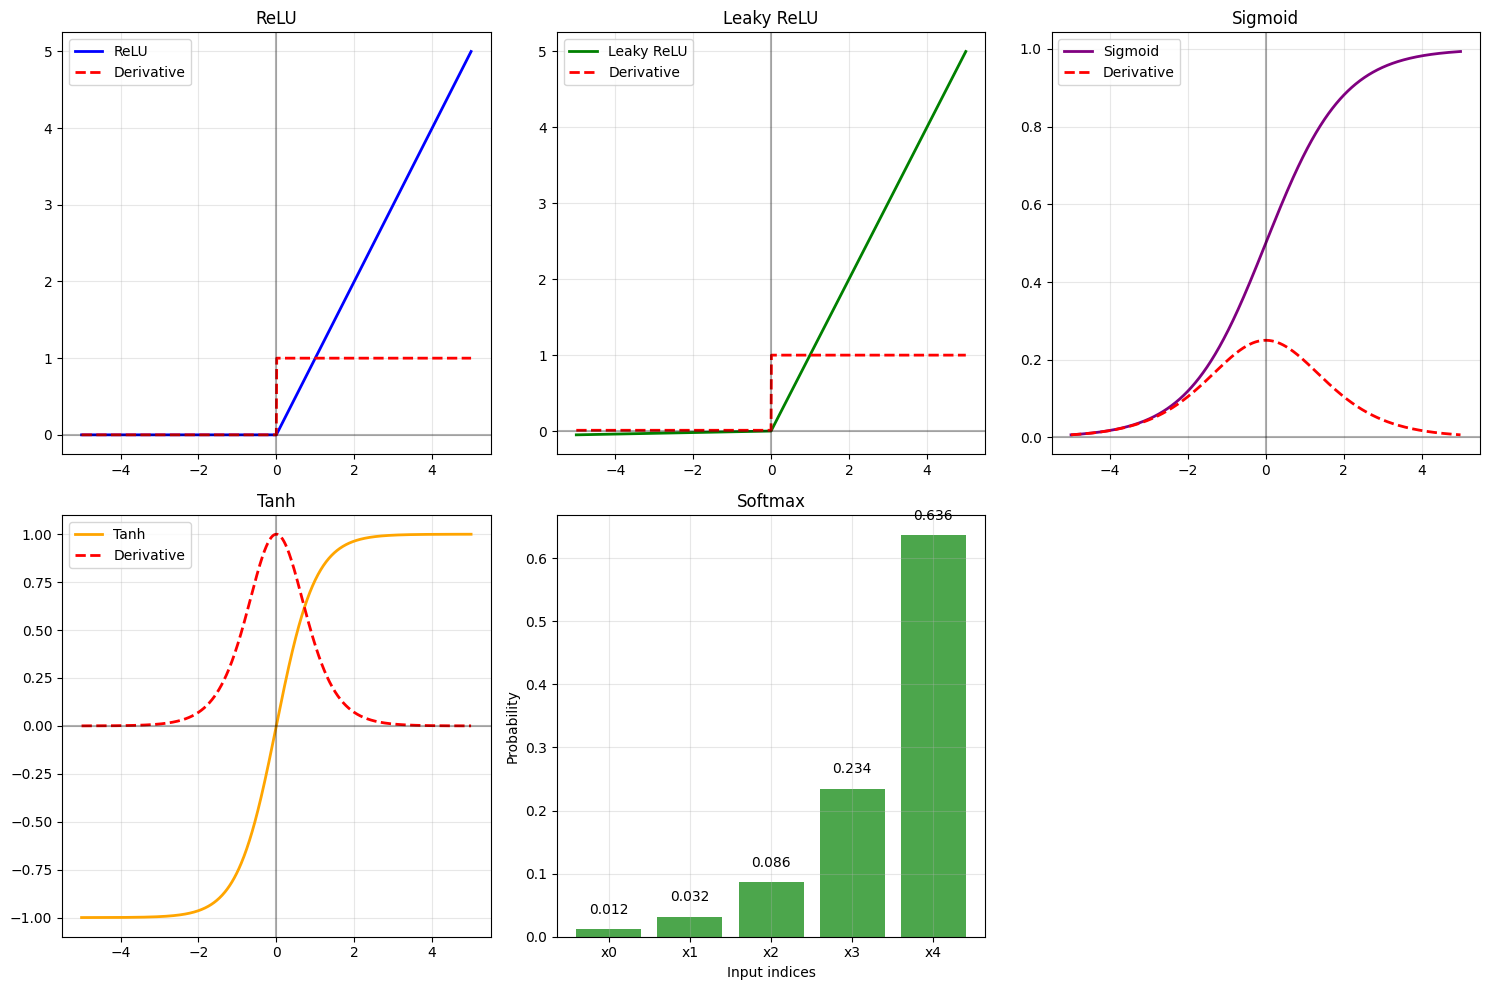

BATCH PROCESSING (Multiple samples)

 Batch shape: 3 samples × 4 features
Batch data:
   Sample 1: [0.5, -1.2, 2.0, -3.5]
   Sample 2: [-0.8, 1.5, -2.1, 0.3]
   Sample 3: [1.0, -0.5, 1.8, -1.0]

 ReLU output:
   Sample 1: [0.5, 0, 2.0, 0]
   Sample 2: [0, 1.5, 0, 0.3]
   Sample 3: [1.0, 0, 1.8, 0]

 Softmax output (per sample):
   Sample 1: [0.176, 0.0321, 0.7887, 0.0032]
   Sum: 1.0000
   Sample 2: [0.0702, 0.6999, 0.0191, 0.2108]
   Sum: 1.0000
   Sample 3: [0.279, 0.0623, 0.621, 0.0378]
   Sum: 1.0000


In [19]:

if __name__ == "__main__":
    demo_usage()
    comparison_table()
    visualize_activations()
    batch_example()